# Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Evaluating INQUIRE Benchmarks 

Here we will evaluate the raw query metrics returned by INQUIRE_benchmark for a *vector searh only* ablation study. These raw metrics were calculated using [INQUIRE-Benchmark-small](https://huggingface.co/datasets/sagecontinuum/INQUIRE-Benchmark-small) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it), and set to **response_limit=50**. This means it will return up to 50 images. This was configured this way because INQUIRE uses the top 50 as well to benchmark models. The ablation study purposely removes the keyword search (BM25). This study will help understand how much the keyword serch is helping with retrieval.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.
>NOTE: INQUIRE also provides a [leaderboard](https://inquire-benchmark.github.io/). This is helpful for comparing our results.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` integrated which included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using the gemma-4-31B-it model.
- **Vector Search**: Utilizes embeddings of both the images and their captions to perform semantic search on **CLIP's** imbedding space.
- **NO Keyword Search**: Searches are NOT also performed using keywords extracted from image captions.
- **NO Hybrid Search**: ONLY a vector search is performed to return the most relevant results.
- **[ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) for Reranker**: A model that refines the order of search results, ensuring that the most relevant documents or items are ranked higher. It goes beyond the initial retrieval step, considering additional factors such as semantic similarity, context, and other relevant features.

Here were the Hyperparameters used for the image search:

In [4]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'alpha': 1.0, 'query_properties': ['caption']...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
3,embed_caption,True,bool
4,embed_image,True,bool
5,enable_bm25,False,bool
6,enable_caption_generation,True,bool
7,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
8,hnsw_dynamicEfMax,500,int
9,hnsw_dynamicEfMin,200,int


## Query and Image Collection Process

This explanation was grabbed from the [INQUIRE paper](https://arxiv.org/abs/2411.02537) so that we can better understand the results in further sections

### Query Collection
To ensure that INQUIRE comprises text queries that are relevant to scientists,
we conducted interviews with individuals across different ecological and environmental domains -
including experts in ornithology, marine biology, entomology, and forestry. Further queries were
sourced from reviews of academic literature in ecology. We retained only queries that (1) could be discerned from images
alone, (2) were feasible to comprehensively label over the entire iNat24 dataset, and (3) were of
interest to domain experts.

### Image Annotation
All image annotations were performed by a small set of individuals whose
interest and familiarity with wildlife image collections enabled them to provide accurate labels for
challenging queries. Annotators were instructed to label all candidate images as either relevant (i.e.,
positive match) or not relevant (i.e., negative match) to a query, and to mark an image as not relevant
if there was reasonable doubt. To allow for comprehensive labeling, where applicable, iNat24 species
labels were used to narrow down the search to a sufficiently small size to label all relevant images for
the query of interest. For queries in which species labels could not be used, labeling was performed
over the top CLIP ViT-H-14 retrievals alone. In this case, the resulting annotations were only
kept if we were certain that this labeling captured the vast majority of positives, including labeling
until at least 100 consecutive retrievals were not relevant. Queries that were deemed
too easy, not comprehensively labeled, or otherwise not possible to label were excluded from our
benchmark. In total, this process resulted in 250 queries which involved labeling 194,334 images, of
which 32,696 were relevant to their query.

### Query Categories
Each query belongs to one of four supercategories (appearance, behavior,
context, or species), and further into one of sixteen fine-grained categories (e.g., Animal Structures
and Habitats). We also note
queries that use scientific terminology, words typically used only within scientific contexts (e.g., “A
godwit performing distal rhynchokinesis”).

### Data Split
We divide all queries into 50 validation and 200 test queries using a random split,
stratified by category.

## Query Coverage

Queries cover a range of topics and a organism taxonomies:

![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_iconic_groups.png?raw=1)
![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_categories.png?raw=1)

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries created by the INQUIRE authors.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: Measures whether at least one relevant result appears in the results. To get hit rate we take the mean of the hit column.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP ViT-H-14 was used by the INQUIRE authors to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rerank_score_reciprocal_rank**: The reciprocal rank of the rerank scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on rerank_score column.
- **clip_score_reciprocal_rank**: The reciprocal rank of the clip scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on clip_score column.
- **category**: The category given to the query by the INQUIRE authors. (ex; Defensive and Survival Behaviors)
- **supercategory**: The supercategory given the the query by the INQUIRE authors. (ex; Behavior)
- **iconic_group**: The iconic group given to the query by the INQUIRE authors. (ex; Mammals)

NOTE: k=response_limit


In [5]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg colums
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG', 
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,diversity,NDCG,clip_NDCG,rr,clip_rr,category,supercategory,iconic_group
0,11,A mongoose standing upright alert,50,50,0,21.0,29.0,1.00,0.42,0.807692,1,0.165874,0.881684,0.952373,1.000000,1.000000,Defensive and Survival Behaviors,Behavior,Mammals
1,189,puffins carrying food,50,50,0,7.0,43.0,1.00,0.14,0.875000,1,0.197034,0.642680,0.558596,0.500000,0.333333,Feeding and Hydration,Behavior,Birds
2,6,A female pheasant,50,50,0,30.0,20.0,1.00,0.60,0.731707,1,0.205251,0.927112,0.925292,1.000000,1.000000,Sex identification,Appearance,Birds
3,32,Dead hog-nosed skunk,50,50,0,18.0,32.0,1.00,0.36,0.600000,1,0.156809,0.835410,0.873549,1.000000,1.000000,Health and Disease,Appearance,Mammals
4,66,Mushrooms growing in a fairy ring formation,50,50,0,6.0,44.0,1.00,0.12,0.750000,1,0.194920,0.942244,0.683935,1.000000,1.000000,Miscellaneous Context,Context,Fungi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,152,feral cat with prey,50,50,0,14.0,36.0,1.00,0.28,1.000000,1,0.318388,0.743546,0.850870,0.500000,1.000000,Feeding and Hydration,Behavior,Mammals
156,43,Fur seal mother with pup,50,50,0,18.0,32.0,1.00,0.36,0.620690,1,0.181546,0.760380,0.914697,1.000000,1.000000,Cooperative and Social Behaviors,Behavior,Mammals
157,47,Haliaeetus eagles in aerial cartwheeling fligh...,50,50,0,1.0,49.0,1.00,0.02,1.000000,1,0.206630,0.630930,0.194959,0.500000,0.029412,"Mating, Courtship, Reproduction",Behavior,Birds
158,0,A By-the-Wind Sailor washed up on a beach,50,43,7,1.0,49.0,0.86,0.02,0.500000,1,0.235134,0.402367,0.739925,0.250000,1.000000,Health and Disease,Appearance,Animalia


## Overall Metrics
First, we will begin with evaluating all queries.

In [6]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()


# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")


total_images: 8000
correctly_returned: 7563
incorrectly_returned: 437
relevant_images: 1996.0
non_relevant_images: 6004.0
accuracy: 0.945375
precision: 0.2495
recall: 0.7092724849329793
hit_rate: 0.9875
NDCG: 0.6742888161284656
clip_NDCG: 0.709594565925853
mrr: 0.6213205627936729
clip_mrr: 0.6793034198500335
diversity: 0.18527676261666967

Insights:
The system returned a total of 7563 correct images out of 8000 total images returned.
The accuracy of the system is 0.9454, indicating that 94.54% of the returned images correctly matched with the query.
The precision of the system is 0.2495, indicating that 24.95% of the total images returned were relevant images.
The recall of the system is 0.7093, indicating that 70.93% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.9875, indicating that 98.75% of the total queries processed had at least one relevant image.
The NDCG score is 0.6743, and the Clip NDCG score is 0.7096, indicating the ranking qual

## Metrics based on Supercategory

Now, we will evaluate queries based on their categories.


In [7]:
# Group by category and calculate the sum/mean of each metric
supercategory_metrics = df.groupby('supercategory').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

supercategory_metrics

,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Appearance,2600,2473,127,564.0,2036.0,0.951154,0.216923,0.655200,1.000000,0.604263,0.665804,0.525802,0.620583,0.174361
1,Behavior,2950,2823,127,782.0,2168.0,0.956949,0.265085,0.782330,1.000000,0.705022,0.759257,0.667245,0.727578,0.185044
2,Context,2150,1976,174,568.0,1582.0,0.919070,0.264186,0.706913,0.953488,0.732642,0.711335,0.706323,0.715436,0.202861
3,Species,300,291,9,82.0,218.0,0.970000,0.273333,0.476421,1.000000,0.560775,0.588286,0.388377,0.454557,0.156151


### Accuracy

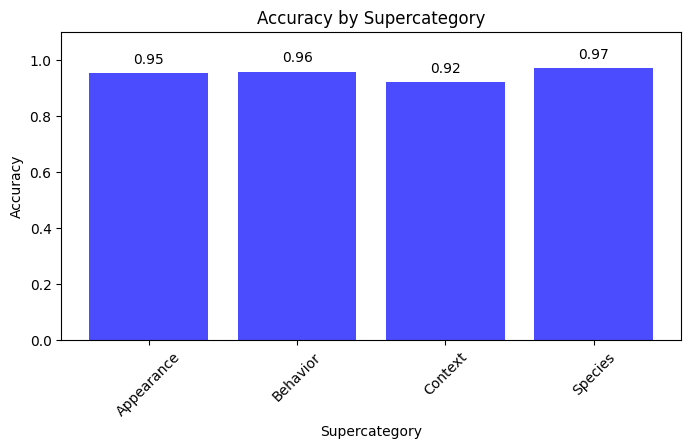

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Supercategory")
ax.set_title("Accuracy by Supercategory")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

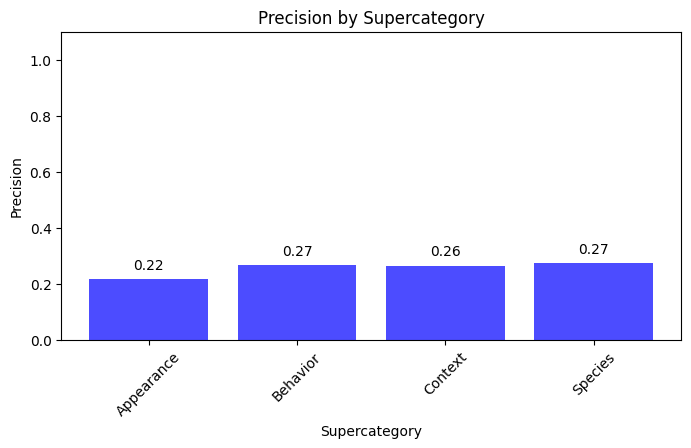

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Supercategory")
ax.set_title("Precision by Supercategory")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

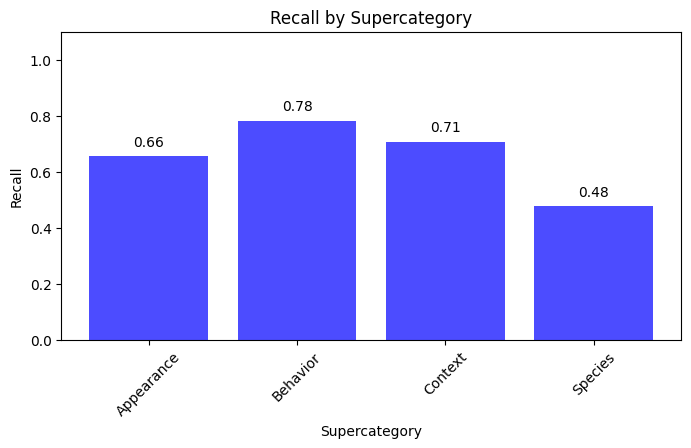

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Supercategory")
ax.set_title("Recall by Supercategory")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

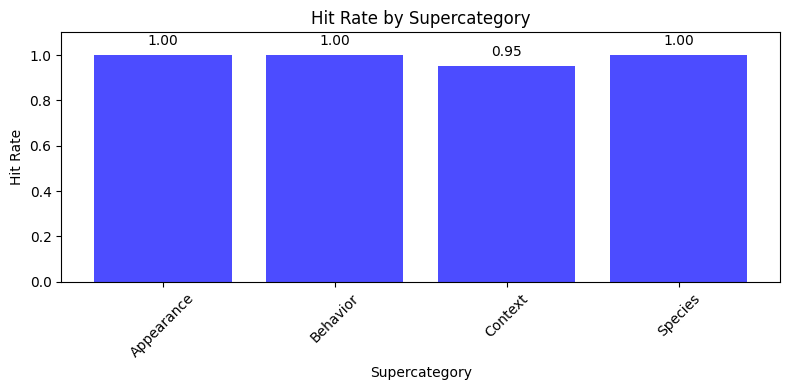

In [11]:
# Hit Rate by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Supercategory")
ax.set_title("Hit Rate by Supercategory")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


Text(0.5, 1.0, 'Diversity by Supercategory')

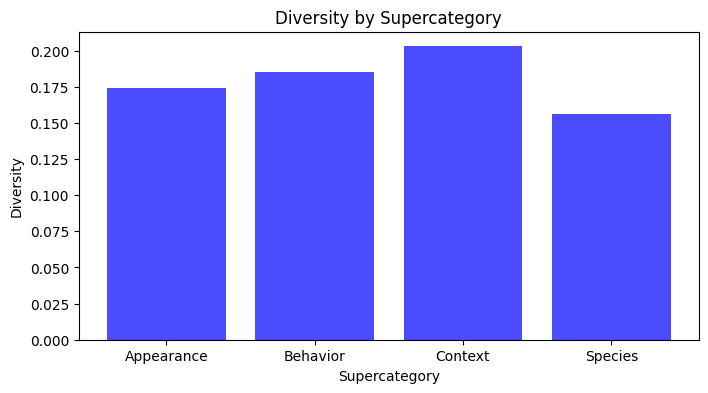

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['diversity'], color="blue", alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Supercategory")
ax.set_title("Diversity by Supercategory")

### NDCG

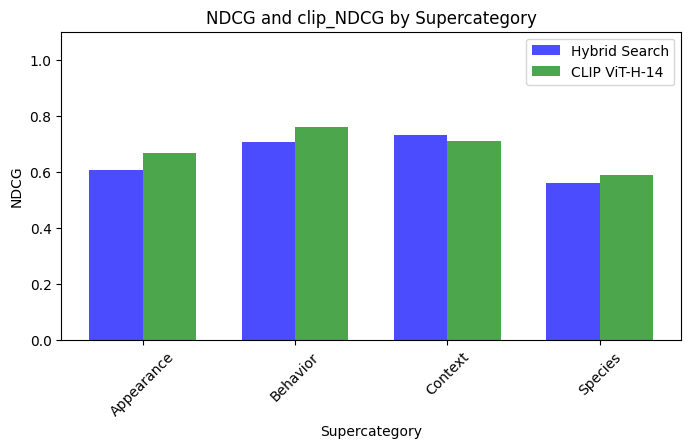

In [13]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Supercategory")
ax.set_title("NDCG and clip_NDCG by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

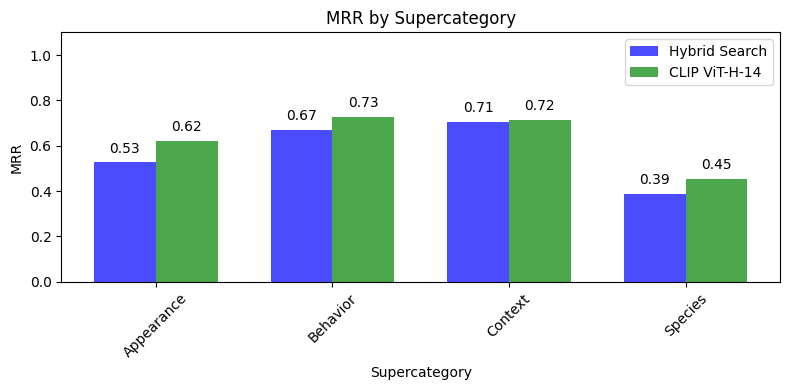

In [14]:
# MRR and clip_MRR by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Supercategory")
ax.set_title("MRR by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Metrics based on Category

In [15]:
# Group by category and calculate the sum/mean of each metric while keeping supercategory
category_metrics = df.groupby(['category']).agg({
    'supercategory': 'first',  # Assuming each category has a single supercategory
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).sort_values(by="supercategory").reset_index()

category_metrics

,category,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Health and Disease,Appearance,600,550,50,148.0,452.0,0.916667,0.246667,0.627409,1.000000,0.586616,0.734321,0.514703,0.745370,0.184103
1,Life Cycle and Development,Appearance,750,723,27,143.0,607.0,0.964000,0.190667,0.610024,1.000000,0.511089,0.581186,0.370262,0.539794,0.175640
2,Sex identification,Appearance,400,400,0,94.0,306.0,1.000000,0.235000,0.563143,1.000000,0.571903,0.562486,0.480702,0.482989,0.158081
3,Tracking and Identification,Appearance,400,389,11,105.0,295.0,0.972500,0.262500,0.665362,1.000000,0.855232,0.829276,0.854167,0.881944,0.147242
4,Unique appearances or morphs,Appearance,450,411,39,74.0,376.0,0.913333,0.164444,0.840341,1.000000,0.588761,0.662008,0.548044,0.478836,0.197820
5,Cooperative and Social Behaviors,Behavior,900,849,51,276.0,624.0,0.943333,0.306667,0.771841,1.000000,0.739216,0.803273,0.759259,0.814815,0.175916
6,Defensive and Survival Behaviors,Behavior,400,396,4,100.0,300.0,0.990000,0.250000,0.720101,1.000000,0.592788,0.837432,0.493547,0.875000,0.189920
7,Feeding and Hydration,Behavior,850,808,42,130.0,720.0,0.950588,0.152941,0.808693,1.000000,0.641899,0.643653,0.561905,0.520127,0.204247
8,"Mating, Courtship, Reproduction",Behavior,550,531,19,151.0,399.0,0.965455,0.274545,0.829339,1.000000,0.774330,0.759244,0.795455,0.734997,0.167183
9,Miscellaneous Behavior,Behavior,250,239,11,125.0,125.0,0.956000,0.500000,0.726599,1.000000,0.823639,0.868807,0.690000,0.866667,0.184104


In [16]:
# Define colors for each supercategory
supercategory_colors = {
    "Context": "red",
    "Behavior": "green",
    "Appearance": "blue",
    "Species": "orange"
}

# Assign colors based on supercategory
colors = [supercategory_colors[sc] for sc in category_metrics['supercategory']]

# Bar width
bar_width = 0.35
x = np.arange(len(category_metrics['category']))

### Accuracy

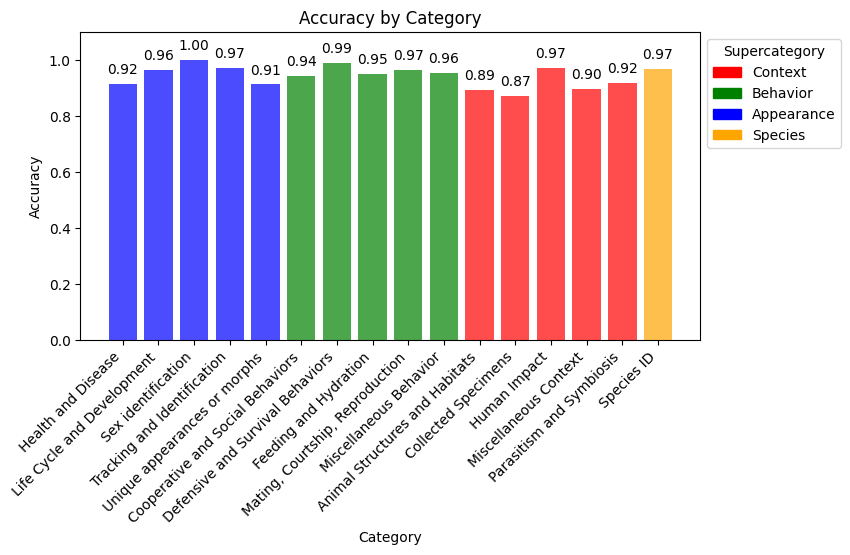

In [17]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['accuracy'], color=colors, alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Category")
ax.set_title("Accuracy by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Precision

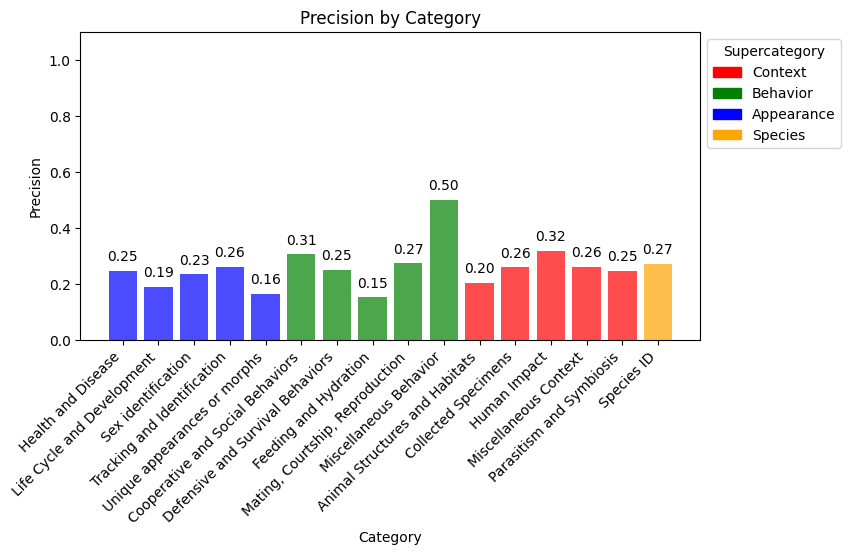

In [18]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['precision'], color=colors, alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Category")
ax.set_title("Precision by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Recall

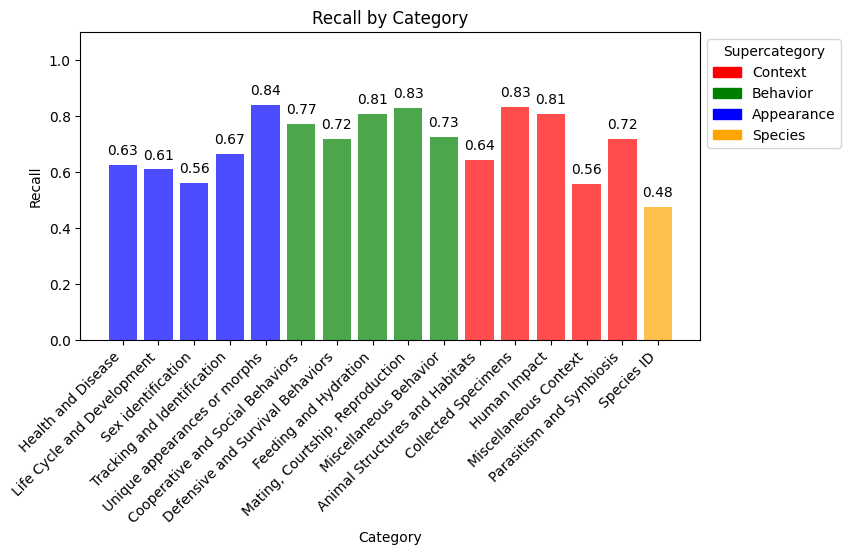

In [19]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['recall'], color=colors, alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Category")
ax.set_title("Recall by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Hit Rate

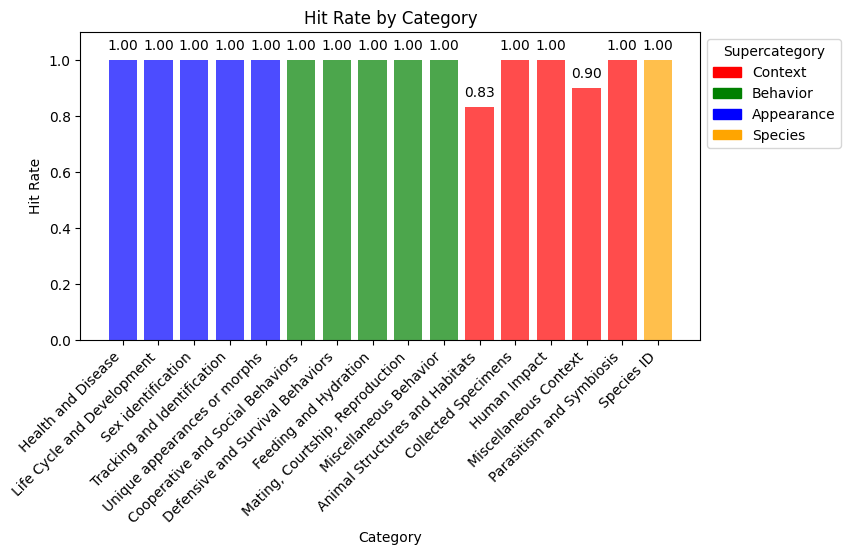

In [20]:
# Hit Rate by Category
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['hit'], color=colors, alpha=0.7)

ax.set_ylabel("Hit Rate")
ax.set_xlabel("Category")
ax.set_title("Hit Rate by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Diversity

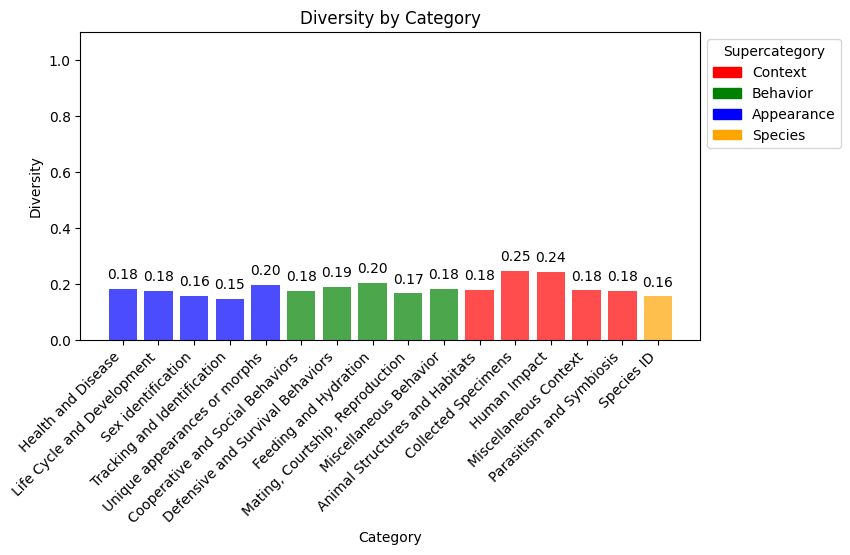

In [21]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['diversity'], color=colors, alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Category")
ax.set_title("Diversity by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### NDCG

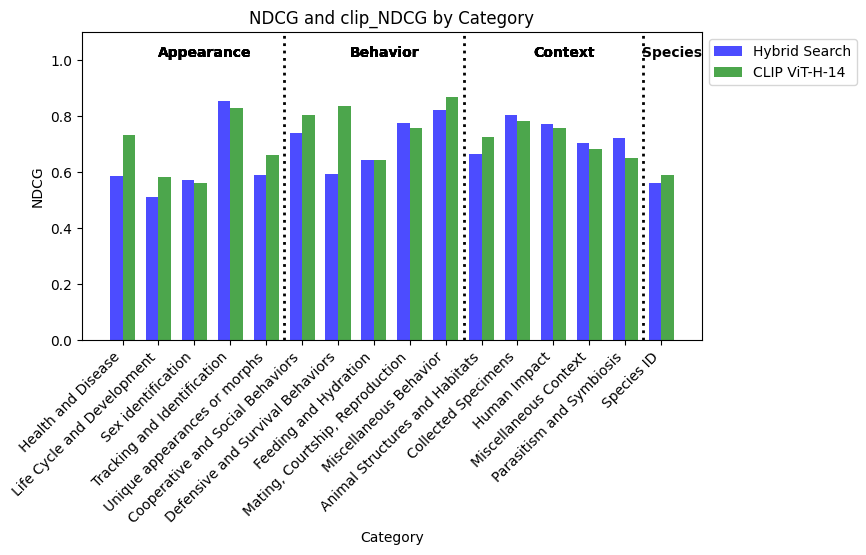

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create side-by-side bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, category_metrics['NDCG'], width=bar_width,
               label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_NDCG'], width=bar_width,
               label="CLIP ViT-H-14", color="green", alpha=0.7)

# Set x-ticks and category labels
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# add labels and titles
ax.set_ylabel("NDCG")
ax.set_xlabel("Category")
ax.set_title("NDCG and clip_NDCG by Category")
ax.set_ylim(0, 1.1)  # Increase top limit to make room for supercategory labels
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Add dotted vertical lines between supercategory groups
supercats = category_metrics['supercategory'].values
for i in range(1, len(supercats)):
    if supercats[i] != supercats[i-1]:
        # Place line halfway between bars at index i-0.5
        ax.axvline(x=i - 0.5, color='black', linestyle=':', linewidth=2)

# Add supercategory labels above the groups
for supercat in category_metrics['supercategory']:
    # Find indices for current supercategory
    indices = np.where(category_metrics['supercategory'] == supercat)[0]
    # Calculate the center position for the group
    center_x = ((indices[0] + indices[-1]) / 2) + 0.3
    # Add the supercategory label above the bars
    ax.text(center_x, 1.0, supercat, ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.show()

### MRR

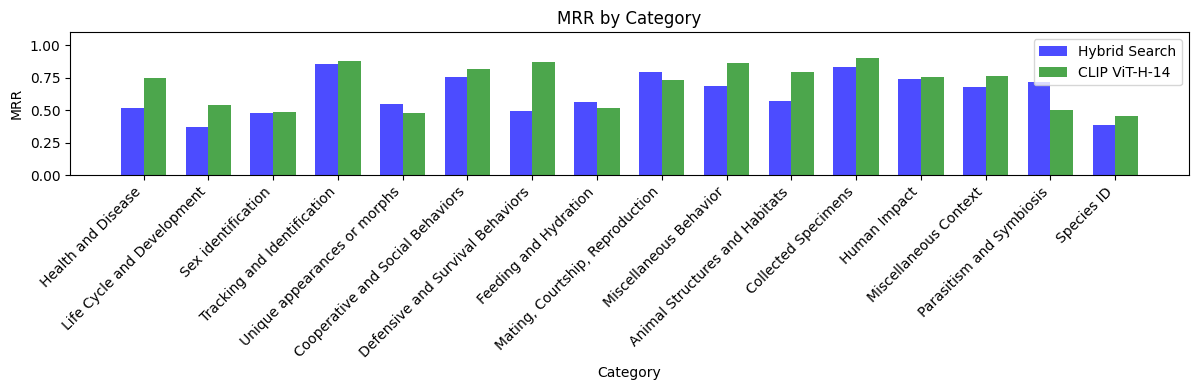

In [23]:
# MRR and clip_MRR by Category
fig, ax = plt.subplots(figsize=(12, 4))
bar_width = 0.35
x = np.arange(len(category_metrics['category']))
bars1 = ax.bar(x - bar_width/2, category_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Category")
ax.set_title("MRR by Category")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Metrics based on Iconic Group

In [24]:
# Group by iconic_group and calculate the sum/mean of each metric
iconic_metrics = df.groupby(['iconic_group']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

iconic_metrics

,iconic_group,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Amphibians,200,198,2,39.0,161.0,0.990000,0.195000,0.760490,1.000000,0.618885,0.561312,0.520833,0.424603,0.167932
1,Animalia,150,143,7,16.0,134.0,0.953333,0.106667,0.621212,1.000000,0.584696,0.669930,0.458333,0.714286,0.192284
2,Arachnids,350,324,26,57.0,293.0,0.925714,0.162857,0.573583,0.857143,0.425866,0.507597,0.311442,0.475630,0.150296
3,Birds,2000,1990,10,514.0,1486.0,0.995000,0.257000,0.748746,1.000000,0.705302,0.723698,0.688889,0.712951,0.193138
4,Combo,50,50,0,24.0,26.0,1.000000,0.480000,0.857143,1.000000,0.794660,0.957453,0.333333,1.000000,0.185157
5,Fish,350,347,3,88.0,262.0,0.991429,0.251429,0.619882,1.000000,0.608302,0.623035,0.487555,0.519424,0.183458
6,Fungi,300,300,0,97.0,203.0,1.000000,0.323333,0.605183,1.000000,0.817632,0.709770,0.833333,0.644444,0.154402
7,Insects,1250,1073,177,212.0,1038.0,0.858400,0.169600,0.649345,0.960000,0.551649,0.619966,0.420103,0.576644,0.172228
8,Mammals,2400,2250,150,728.0,1672.0,0.937500,0.303333,0.776349,1.000000,0.772187,0.815016,0.774470,0.825740,0.195312
9,Mollusks,200,158,42,44.0,156.0,0.790000,0.220000,0.491998,1.000000,0.568573,0.621217,0.309615,0.400000,0.194652


In [25]:
# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

### Accuracy

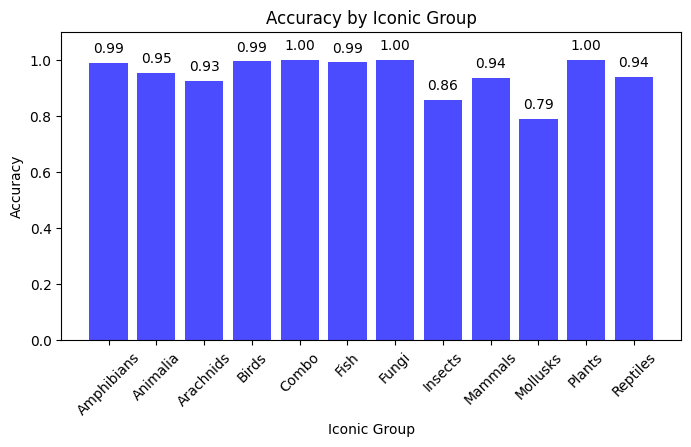

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Iconic Group")
ax.set_title("Accuracy by Iconic Group")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

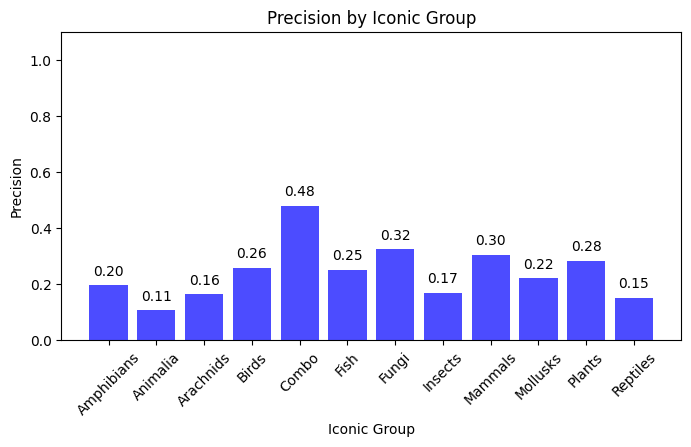

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Iconic Group")
ax.set_title("Precision by Iconic Group")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

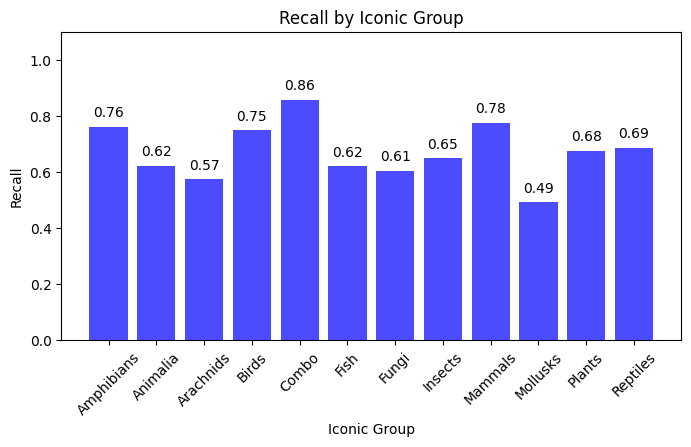

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Iconic Group")
ax.set_title("Recall by Iconic Group")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

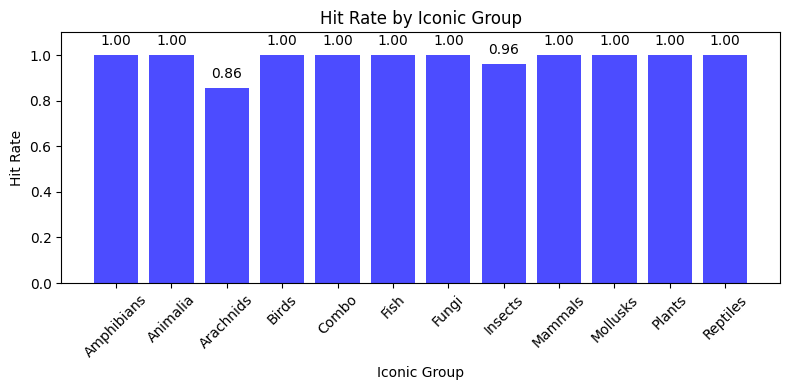

In [29]:
# Hit Rate by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Iconic Group")
ax.set_title("Hit Rate by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


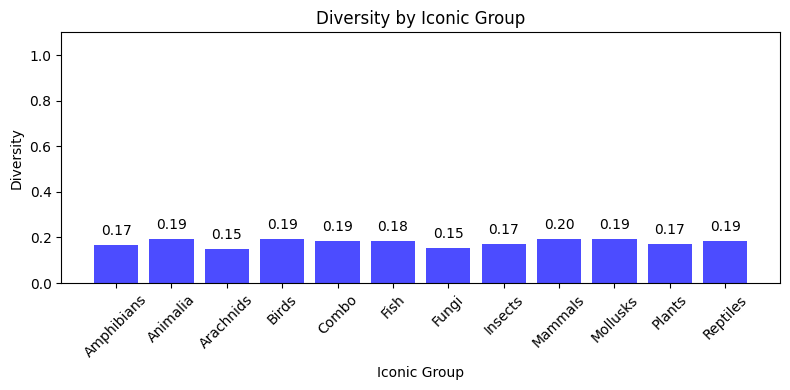

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['diversity'], color="blue", alpha=0.7)
ax.set_ylabel("Diversity")
ax.set_xlabel("Iconic Group")
ax.set_title("Diversity by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### NDCG

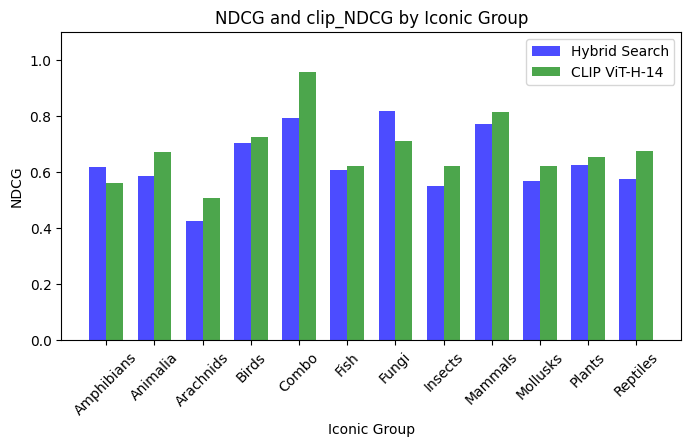

In [31]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, iconic_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Iconic Group")
ax.set_title("NDCG and clip_NDCG by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

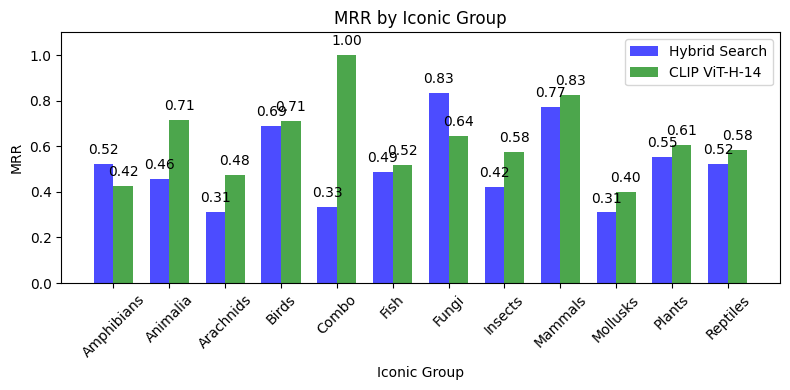

In [32]:
# MRR and clip_MRR by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))
bars1 = ax.bar(x - bar_width/2, iconic_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Iconic Group")
ax.set_title("MRR by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Displaying Metrics used in Leaderboard

Here we will show the metrics used in [INQUIRE's leaderboard](https://inquire-benchmark.github.io/) to be able to see how our Hybrid Search is doing when compared to their leaderboard.

In [33]:
ldboard = {
    "Method": "Hybrid Search",
    "Overall": overall_metrics['precision'],
    "Appearance": supercategory_metrics[supercategory_metrics['supercategory']== 'Appearance']['precision'][0],
    "Behavior": supercategory_metrics[supercategory_metrics['supercategory']== 'Behavior']['precision'][1],
    "Context": supercategory_metrics[supercategory_metrics['supercategory']== 'Context']['precision'][2],
    "Species": supercategory_metrics[supercategory_metrics['supercategory']== 'Species']['precision'][3]

}
# Convert the dictionary to a DataFrame
ldboard_df = pd.DataFrame([ldboard])
ldboard_df

,Method,Overall,Appearance,Behavior,Context,Species
0,Hybrid Search,0.2495,0.216923,0.265085,0.264186,0.273333


## Comparing v10 to v11

## Insights & Conclusion

**System Differences**

Three runs on the same 160 queries × 50 results (8,000 images):

- **Baseline (b)** — `openai/clip-vit-base-patch32`, no caption generation, image-only indexing (`embed_image=true`, `embed_caption=false`), vector-only retrieval (`enable_bm25=false`, `alpha=1.0`).
- **Vector Search Only (a)** — `DFN5B-CLIP-ViT-H-14-378` with Gemma captions, fused image + caption embeddings (`embed_image=true`, `embed_caption=true`, `index_clip_alpha=0.7`), but **keyword search disabled** (`enable_bm25=false`, `alpha=1.0`)—pure CLIP vector retrieval with caption reranking.
- **v12** — Same stack as (a) plus **hybrid BM25 keyword search** (`enable_bm25=true`, `alpha=0.4`, `clip_alpha=0.7`).

This isolates how much INQUIRE retrieval comes from keyword/BM25 search on top of production CLIP + caption fusion.

---

**Overall Metrics Comparison**

| Metric                   | Baseline (b) | Vector Search Only (a) |  v12  | Difference (a - b) | Difference (v12 - a) |
| ------------------------ | --- | --- | --- | --- | --- |
| **Total Images**         | 8,000 | 8,000 | 8,000 | 0 | 0 |
| **Correctly Returned**   | 6,359 | 7,563 | 6,855 | +1,204 | −708 |
| **Incorrectly Returned** | 1,641 | 437 | 1,145 | −1,204 | +708 |
| **Relevant Images**      | 1,520 | 1,996 | 1,876 | +476 | −120 |
| **Accuracy**             | 0.7949 | 0.9454 | 0.8569 | +0.1505 | −0.0885 |
| **Precision**            | 0.1900 | 0.2495 | 0.2345 | +0.0595 | −0.0150 |
| **Recall**               | 0.5248 | 0.7093 | 0.6437 | +0.1845 | −0.0656 |
| **Hit Rate**             | 0.9500 | 0.9875 | 0.9375 | +0.0375 | −0.0500 |
| **Diversity**            | 0.1765 | 0.1853 | 0.2179 | +0.0088 | +0.0326 |
| **NDCG**                 | 0.5562 | 0.6743 | 0.6618 | +0.1181 | −0.0125 |
| **clip_NDCG**            | 0.7159 | 0.7096 | 0.7111 | −0.0063 | +0.0015 |
| **MRR**                  | 0.4494 | 0.6213 | 0.5932 | +0.1719 | −0.0281 |
| **clip_MRR**             | 0.7059 | 0.6793 | 0.6805 | −0.0266 | +0.0012 |

---

**Interpretation**

**Vector Search Only (a) is a large upgrade over Baseline (b).** Production DFN CLIP plus fused caption embeddings—without any keyword search—adds +476 relevant images, +3.8 pp hit rate (95.0% → 98.8%), +18.5 pp recall, and +1,204 correctly returned images (accuracy 79.5% → 94.5%). The baseline ViT-B/32 image-only stack leaves substantial labeled relevance on the table even though hit rate was already high.

**Vector Search Only (a) outperforms v12 on core retrieval metrics.** Re-enabling BM25 hybrid search costs −120 relevant images, −5.0 pp hit rate (98.8% → 93.8%), lower recall (−6.6 pp), accuracy (−708 correctly returned), and MRR (−0.028). Keyword overlap on caption text appears to rerank toward lexically similar but visually wrong matches—hurting INQUIRE's human-labeled relevance counts despite modest gains in diversity (+0.033) and clip_MRR.

**Image-only** remains the strongest pure-retrieval run (2,028 relevant, 98.1% hit rate). Vector-only (1,996 relevant, 98.8% hit) is close—caption fusion helps ranking (MRR 0.621 vs image-only 0.584) but slightly trails image-only on raw relevant count. Compared to **caption-only** (1,587 relevant, 91.9% hit), both fused-vector runs dominate; captions without image embeddings cannot match visual retrieval on this benchmark.

---

**Insights**

- **CLIP upgrade + caption fusion carry most of the baseline→production gap.** Vector-only recovers more relevant-image gain over baseline than v12 (+476 vs +356) without any keyword channel.
- **BM25 hurts retrieval on INQUIRE when fused vectors are strong.** Hybrid keyword search degrades hit rate, recall, and accuracy vs vector-only—similar to Commonobjectsbench and Firebench, unlike CloudBench where BM25 adds value.
- **High hit rates mask large accuracy swings.** Baseline and v12 both exceed 93% hit rate, but vector-only's 94.5% accuracy vs v12's 85.7% shows how many returned images are actually labeled relevant—a metric that matters on INQUIRE's dense relevance judgments.
- **Modality ablations converge on image signal.** Image-only and vector-only lead; caption-only and baseline trail; v12 sits between vector-only and image-only on retrieval but below vector-only on every core count metric.

---

**Conclusion**

On INQUIRE, **vector search with production CLIP and fused captions is the strongest fused-stack configuration for labeled relevance**—and it **beats v12's hybrid BM25 layer** on relevant images (+120), hit rate (+5.0 pp), recall, accuracy, and MRR. Disabling keyword search recovers the production gap over baseline more fully than enabling it. **Image-only DFN CLIP remains the top single-modality option** for raw relevant count; deploy fused vectors without BM25 when INQUIRE-style human relevance is the goal, and reserve hybrid keyword search for benchmarks where it demonstrably helps (e.g. CloudBench).

